In [ ]:
import sys
import os

# Get the absolute path of the 'src' directory
src_path = os.path.abspath(os.path.join(os.getcwd(), ".."))  # Move one level up from 'experiments/'

# Add 'src' to Python's module search path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

os.chdir("../")

In [2]:
from pseudoInverse.algorithm4 import DiffusionModel, PiGDM_DDIM
from pseudoInverse.algorithm5 import PiGDM_DDPM
from pseudoInverse.operators import BlurPseudoinverseOperator, InpaintingPseudoinverseOperator, RotationOperator

from ddpm.model import DDPM
from ddpm.utils import save_pilimg, standardize_img, pilimg_to_tensor

from experiments.utils import evaluate_model, ImageDataset, plot_results, compute_psnr

from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

import torch

c:\Users\Mrabe\OneDrive\Bureau\cours MVA\Generative Models\project\PiGDM\src\ddpm\guided_diffusion\unet.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state

## Gaussian Blurring 

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
dataset_path = "dataset/ffhq256-1k-validation"
dataset_size = len(os.listdir(dataset_path))

print(f"The Dataset FFHQ Contains : {dataset_size} Images\n")

# Image Dataset Intialization
dataset = ImageDataset(dataset_path)

The Dataset FFHQ Contains : 1000 Images



Text(0.5, 1.0, 'Image 1')

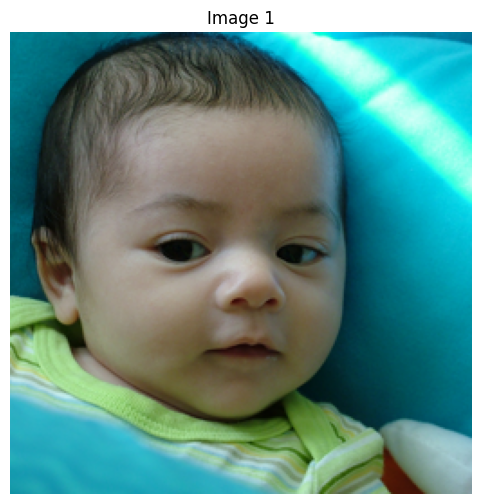

In [9]:
image_1 = standardize_img(dataset[0])

plt.figure(figsize=(6, 6))
plt.imshow(image_1)
plt.axis('off')
plt.title("Image 1")

In [5]:
# Loading Data For Test
subset_size = 10
indices = list(range(subset_size)) 

subset = Subset(dataset, indices)  
test_loader_all = DataLoader(subset, batch_size=1, shuffle=False)

### Sampling Using DDIM

In [12]:
# Create DataLoader
sigma = 100.0
kernel_size = 31 

measurement_operator = BlurPseudoinverseOperator(kernel_size, sigma=sigma)

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

100%|██████████| 100/100 [02:21<00:00,  1.41s/it]


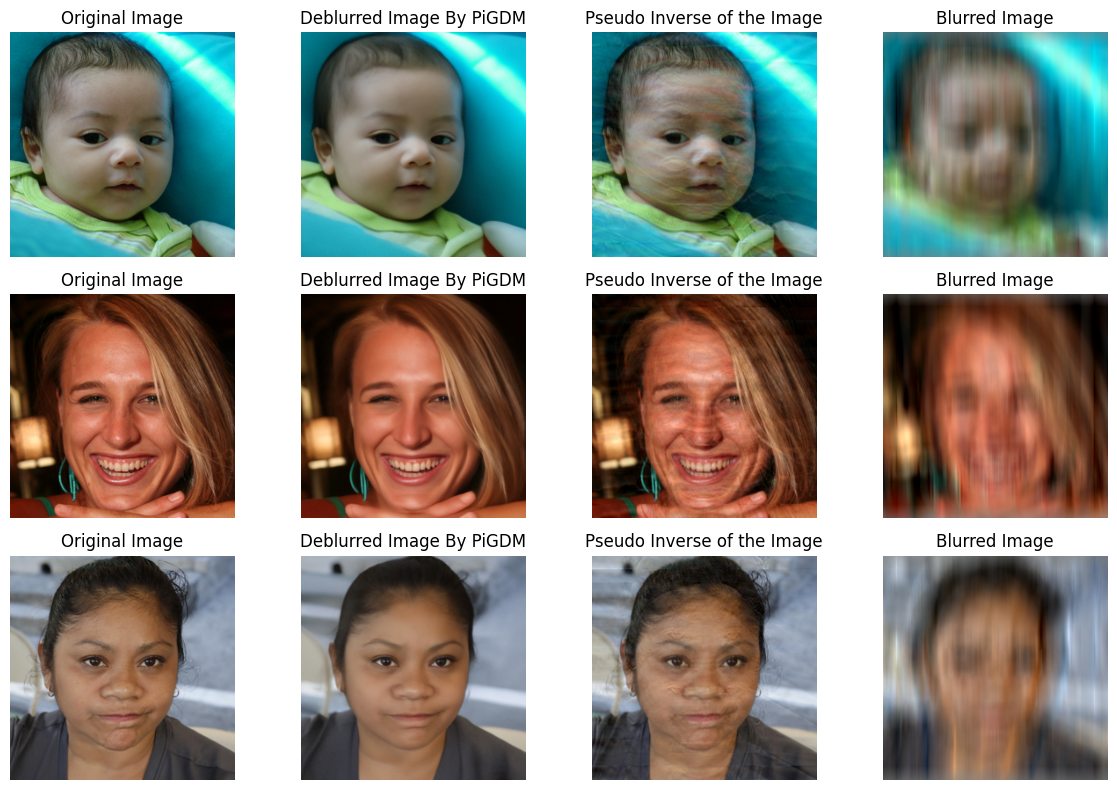

In [16]:
# Running Experiments on The 3 first images
# Noiseless Case

noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    deblurred_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(deblurred_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Deblurred Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Blurred Image")



plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Mrabe\OneDrive\Bureau\cours MVA\Generative Models\project\PiGDM\src\ddpm\model.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [02:23<00:00,  1.44s/it]


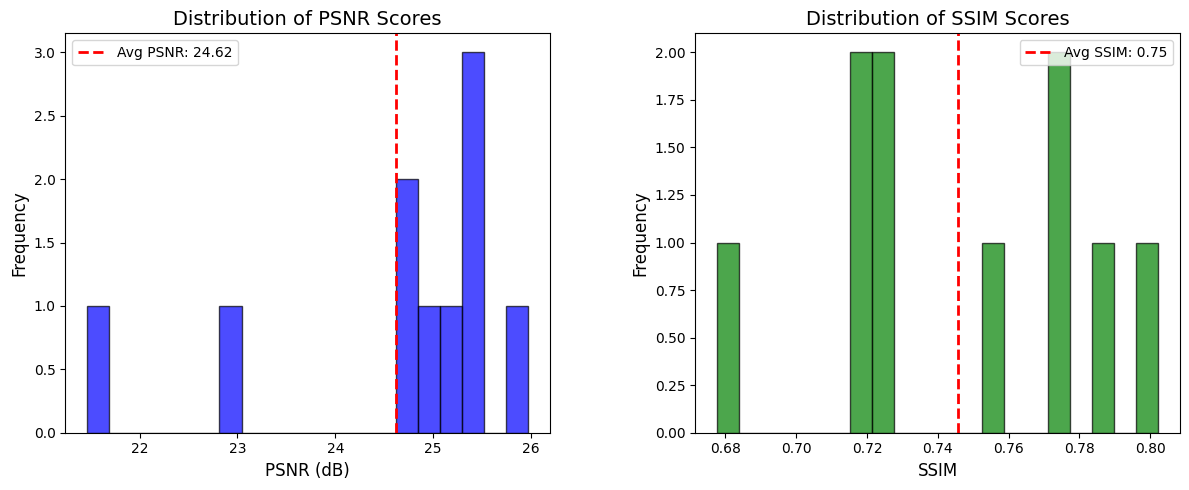

In [ ]:
results_ddim_gaussian_deblur = evaluate_model(pigdm_sampler, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddim_gaussian_deblur)

### Sampling with DDPM

In [17]:
# Create DataLoader
sigma = 100.0
kernel_size = 31 

measurement_operator = BlurPseudoinverseOperator(kernel_size, sigma=sigma)

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler = PiGDM_DDPM(model, measurement_operator, guidance_factor=guidance_factor)

100%|██████████| 100/100 [00:43<00:00,  2.29it/s]


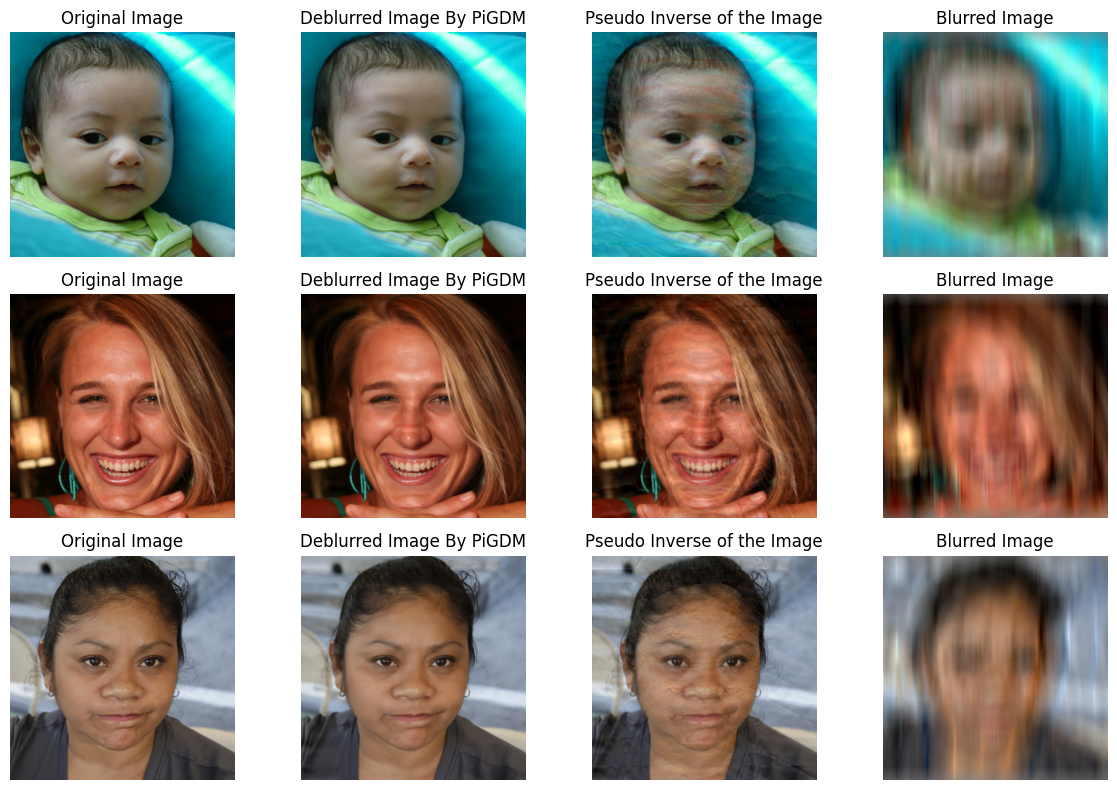

In [18]:
# Running Experiments on The 3 first images
# Noiseless Case

noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    deblurred_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(deblurred_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Deblurred Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Blurred Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:43<00:00,  2.28it/s]


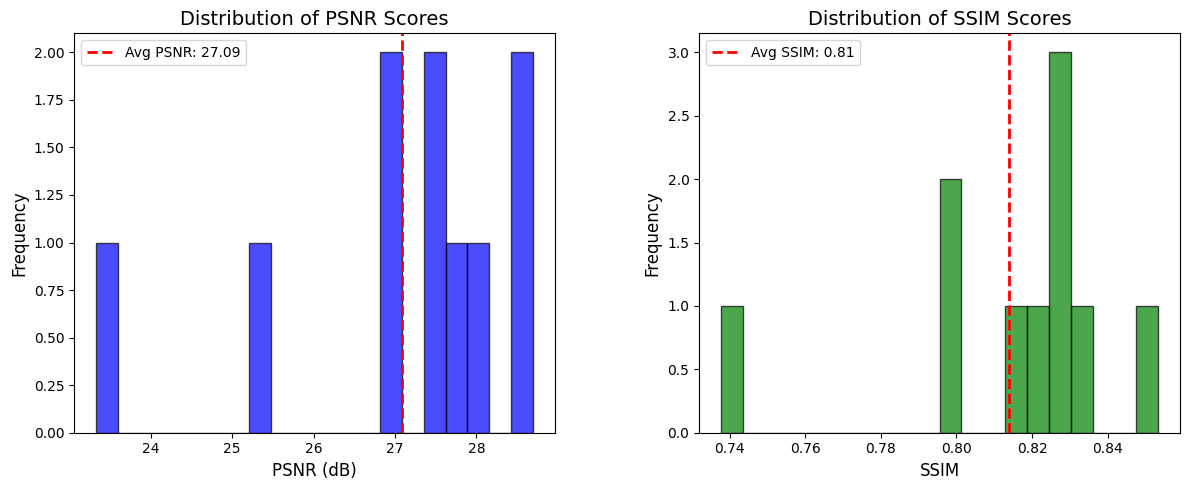

In [19]:
results_ddpm_gaussian_deblur = evaluate_model(pigdm_sampler, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddpm_gaussian_deblur)

### PSNR as a function of Sigma

In [29]:
def psnr_vs_sigma(sigma_values, PIGDM, times=5):
    psnr_values = []
    n = len(dataset)
    for sigma in sigma_values:
        psnr_values_sigma = []
        for _ in range(times):
            # Select Randomly an Image
            idx = np.random.randint(0, n)

            image = dataset[idx].to(device)

            measurement_operator = BlurPseudoinverseOperator(kernel_size, sigma=sigma)
            pigdm_sampler = PIGDM(model, measurement_operator, guidance_factor=guidance_factor)
            y = measurement_operator(image.unsqueeze(0))

            deblurred_image = pigdm_sampler.sample(
                y=y,
                num_steps=num_steps,
                noiseless=noiseless,
                seed=seed
            )
        
            psnr_values_sigma.append(compute_psnr(image.unsqueeze(0), deblurred_image))

        psnr_values.append(sum(psnr_values_sigma) / times)

    return psnr_values


import numpy as np

sigma_values = [1.0, 10.0, 20.0, 50.0, 100.0, 200.0, 1000.0, 5000.0]

# DDPM PSNR vs Sigma
ddpm_psnr_vs_sigma = psnr_vs_sigma(sigma_values, PiGDM_DDPM)
# DDIM PSNR vs Sigma
ddim_psnr_vs_sigma = psnr_vs_sigma(sigma_values, PiGDM_DDIM)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Mrabe\OneDrive\Bureau\cours MVA\Generative Models\project\PiGDM\src\ddpm\model.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [03:12<00:00,  1.92s/it]


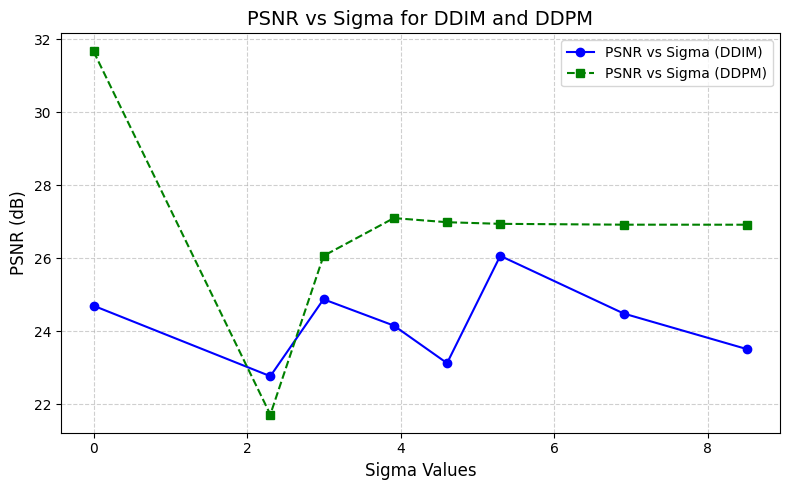

In [30]:
log_sigma_values = [np.log(sigma) for sigma in sigma_values]

plt.figure(figsize=(8, 5))  

# Plot first curve
plt.plot(log_sigma_values, ddim_psnr_vs_sigma, marker='o', linestyle='-', color='b', label="PSNR vs Sigma (DDIM)")

plt.plot(log_sigma_values, ddpm_psnr_vs_sigma, marker='s', linestyle='--', color='g', label="PSNR vs Sigma (DDPM)")

# Labels & Title
plt.xlabel("Sigma Values", fontsize=12)
plt.ylabel("PSNR (dB)", fontsize=12)
plt.title("PSNR vs Sigma for DDIM and DDPM", fontsize=14)

# Grid & Legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

## Inpainting

### DDIM Sampling

In [8]:
img_shape = 256, 256
ratio_mask = 0.3
measurement_operator = InpaintingPseudoinverseOperator(img_shape, ratio_mask, block_size=None, random=True)

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Mrabe\OneDrive\Bureau\cours MVA\Generative Models\project\PiGDM\src\ddpm\model.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [03:03<00:00,  1.83s/it]


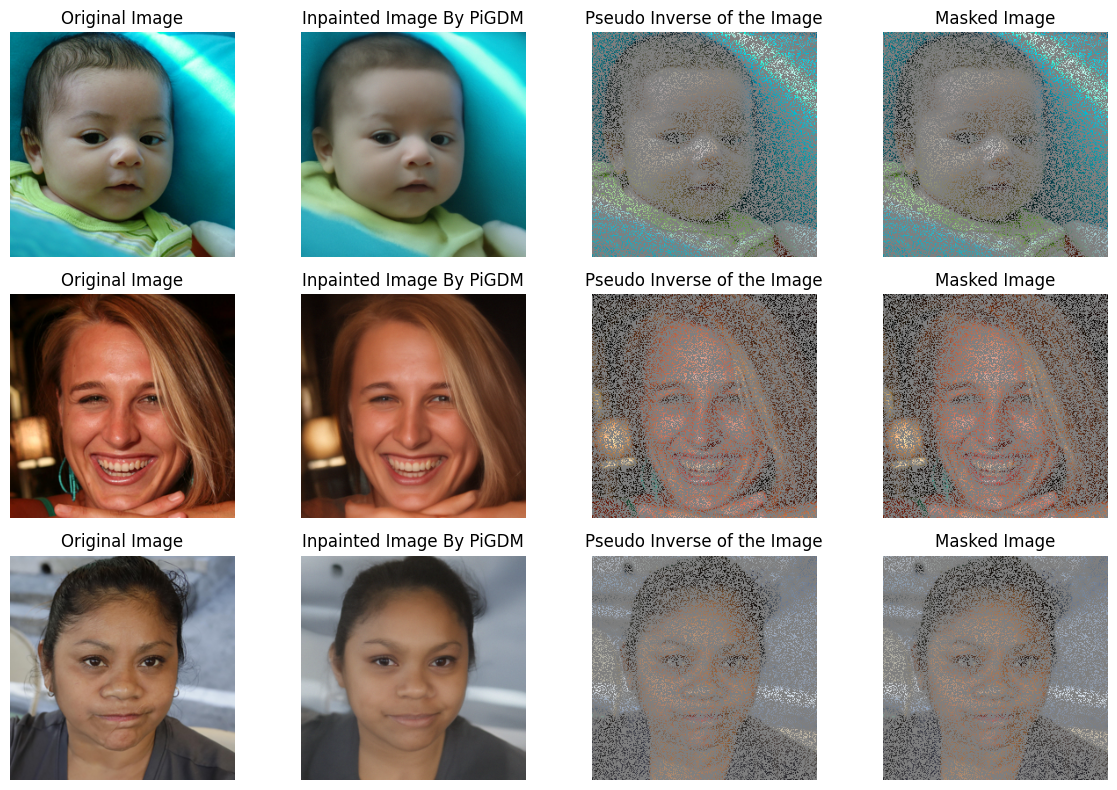

In [35]:
# Running Experiments on The 3 first images

noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    inpainted_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(inpainted_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Inpainted Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Masked Image")



plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Mrabe\OneDrive\Bureau\cours MVA\Generative Models\project\PiGDM\src\ddpm\model.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [02:58<00:00,  1.79s/it]


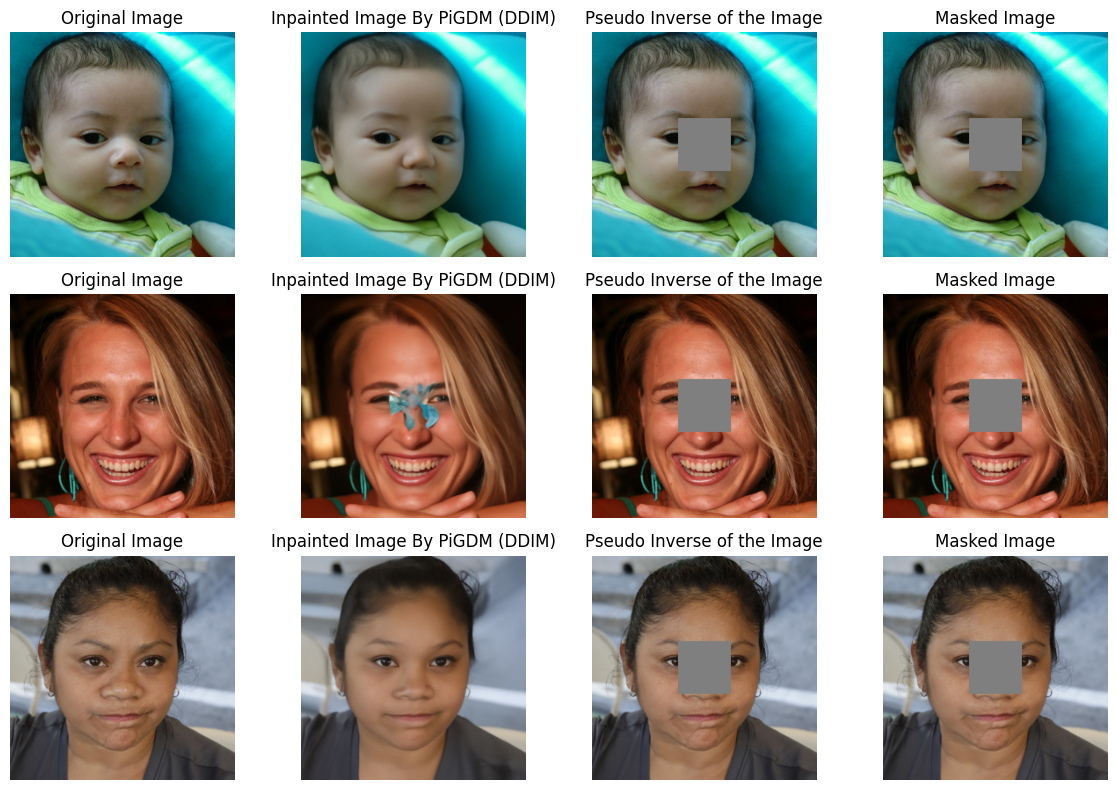

In [9]:
# Running Experiments on The 3 first images
# Here I will use a square mask

noiseless = True
num_steps = 100
seed = 42
random = False
block_size = 60

measurement_operator = InpaintingPseudoinverseOperator(img_shape, ratio_mask=None, block_size=block_size, random=random)

# Initialize sampler
pigdm_sampler_inpainting_block = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    inpainted_image = pigdm_sampler_inpainting_block.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(inpainted_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Inpainted Image By PiGDM (DDIM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Masked Image")



plt.tight_layout()
plt.show()

In [ ]:
results_ddim_inpainting = evaluate_model(pigdm_sampler_inpainting_block, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddim_inpainting)

### DDPM Sampling

In [10]:
# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler_ddpm = PiGDM_DDPM(model, measurement_operator, guidance_factor=guidance_factor)

100%|██████████| 1000/1000 [19:43<00:00,  1.18s/it]


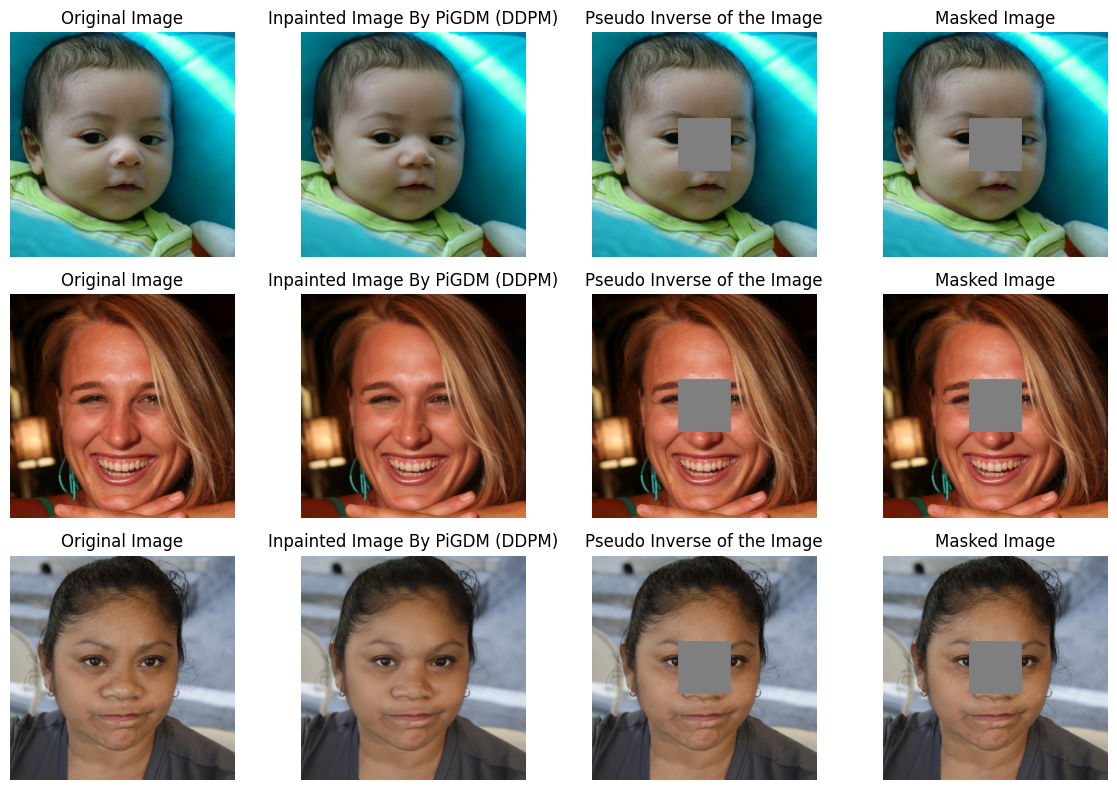

In [11]:
# Running Experiments on The 3 first images

noiseless = True
num_steps = 1000
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    inpainted_image = pigdm_sampler_ddpm.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(inpainted_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Inpainted Image By PiGDM (DDPM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Masked Image")



plt.tight_layout()
plt.show()

In [ ]:
results_ddpm_inpainting = evaluate_model(pigdm_sampler_ddpm, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddpm_inpainting)

## Inpaiting Noisy Case

### DDPM Sampling

In [36]:
img_shape = 256, 256
block_size = 60

measurement_operator = InpaintingPseudoinverseOperator(img_shape, ratio_mask=None, block_size=block_size, random=False)
H = measurement_operator.mask.squeeze(0).squeeze(0)

sigma_y = 0.01
noiseless = False
optimized = False

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler_ddpm = PiGDM_DDPM(model, measurement_operator, measurement_matrix=H, guidance_factor=guidance_factor)

100%|██████████| 100/100 [04:25<00:00,  2.65s/it]


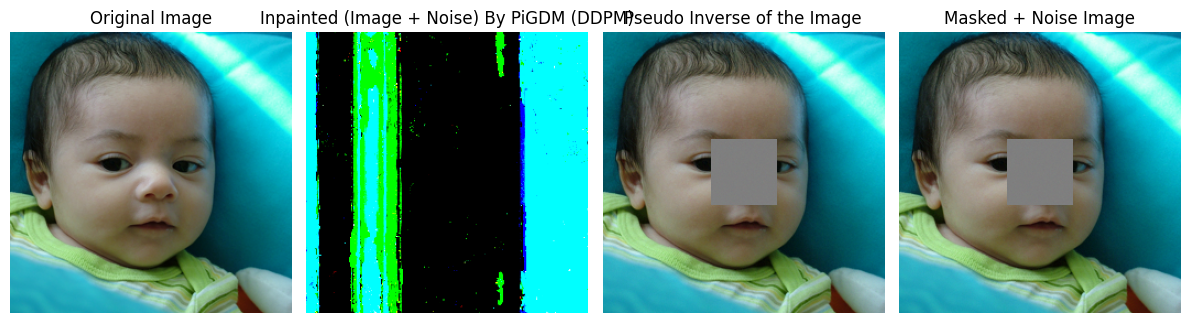

In [37]:
# Running Experiments on The 3 first images
num_steps = 100
seed = 42

fig, axes = plt.subplots(1, 4, figsize=(12, 8))

for i in range(1):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    y += sigma_y * torch.randn_like(y)

    inpainted_image = pigdm_sampler_ddpm.sample(
        y=y,
        num_steps=num_steps,
        sigma_y=sigma_y,
        noiseless=noiseless,
        optimized=optimized,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    # axes[i][0].imshow(standardize_img(image))
    # axes[i][0].axis('off')
    # axes[i][0].set_title("Original Image")

    # axes[i][1].imshow(standardize_img(inpainted_image))
    # axes[i][1].axis('off')
    # axes[i][1].set_title("Inpainted (Image + Noise) By PiGDM (DDPM)")

    # axes[i][2].imshow(standardize_img(inversed_image))
    # axes[i][2].axis('off')
    # axes[i][2].set_title("Pseudo Inverse of the Image")

    # axes[i][3].imshow(standardize_img(y))
    # axes[i][3].axis('off')
    # axes[i][3].set_title("Masked + Noise Image")

    axes[0].imshow(standardize_img(image))
    axes[0].axis('off')
    axes[0].set_title("Original Image")

    axes[1].imshow(standardize_img(inpainted_image))
    axes[1].axis('off')
    axes[1].set_title("Inpainted (Image + Noise) By PiGDM (DDPM)")

    axes[2].imshow(standardize_img(inversed_image))
    axes[2].axis('off')
    axes[2].set_title("Pseudo Inverse of the Image")

    axes[3].imshow(standardize_img(y))
    axes[3].axis('off')
    axes[3].set_title("Masked + Noise Image")


plt.tight_layout()
plt.show()

In [ ]:
results_ddpm_inpainting_noisy = evaluate_model(pigdm_sampler_ddpm, test_loader_all, num_steps, sigma_y=sigma_y, noiseless=noiseless, optimized=optimized, seed=seed, device="cuda")
plot_results(results_ddpm_inpainting_noisy)

### DDIM Sampling

In [38]:
img_shape = 256, 256
block_size = 100

measurement_operator = InpaintingPseudoinverseOperator(img_shape, ratio_mask=None, block_size=block_size, random=False)
H = measurement_operator.mask.squeeze(0).squeeze(0)

sigma_y = 0.05
noiseless = False
optimized = False

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler_ddim = PiGDM_DDIM(model, measurement_operator, measurement_matrix=H, guidance_factor=guidance_factor)

 24%|██▍       | 24/100 [00:25<01:21,  1.08s/it]


KeyboardInterrupt: 

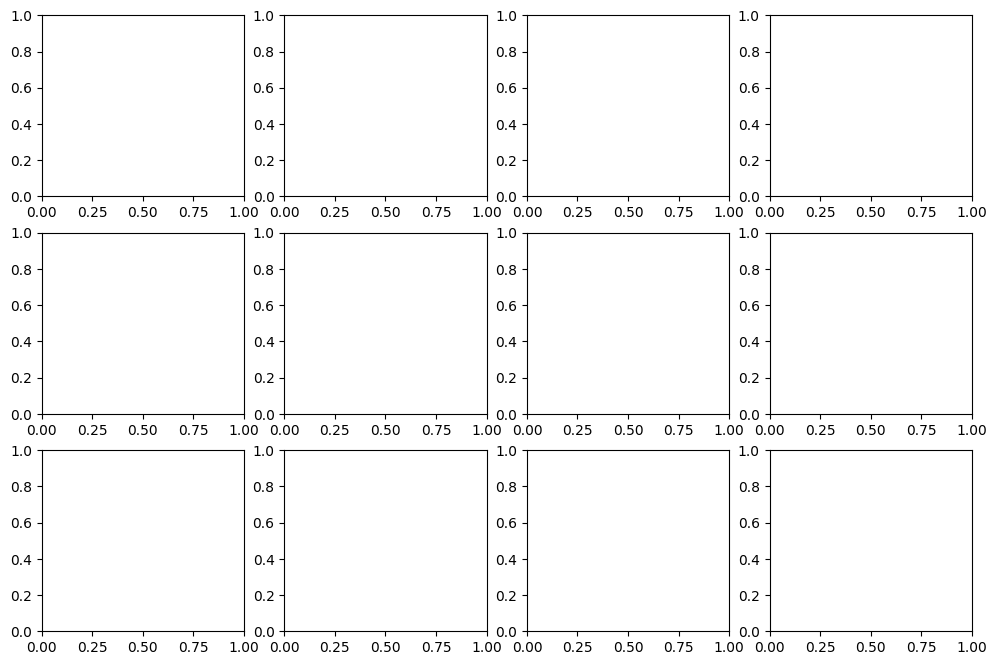

In [41]:
# Running Experiments on The 3 first images
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    y += sigma_y * torch.randn_like(y)

    inpainted_image = pigdm_sampler_ddim.sample(
        y=y,
        num_steps=num_steps,
        sigma_y=sigma_y,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(inpainted_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Inpainted Noisy By PiGDM (DDIM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Masked + Noise Image")


plt.tight_layout()
plt.show()

In [ ]:
results_ddim_inpainting_noisy = evaluate_model(pigdm_sampler_ddim, test_loader_all, num_steps, sigma_y=sigma_y, noiseless=noiseless, optimized=optimized, seed=seed, device="cuda")
plot_results(results_ddim_inpainting_noisy)

## Rotation Operator

### DDIM Sampling

In [42]:
theta = 45 ## In degrees
measurement_operator = RotationOperator(theta)

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm)

guidance_factor = 0.05

# Initialize sampler
pigdm_sampler_rotation_ddim = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

100%|██████████| 100/100 [04:17<00:00,  2.58s/it]


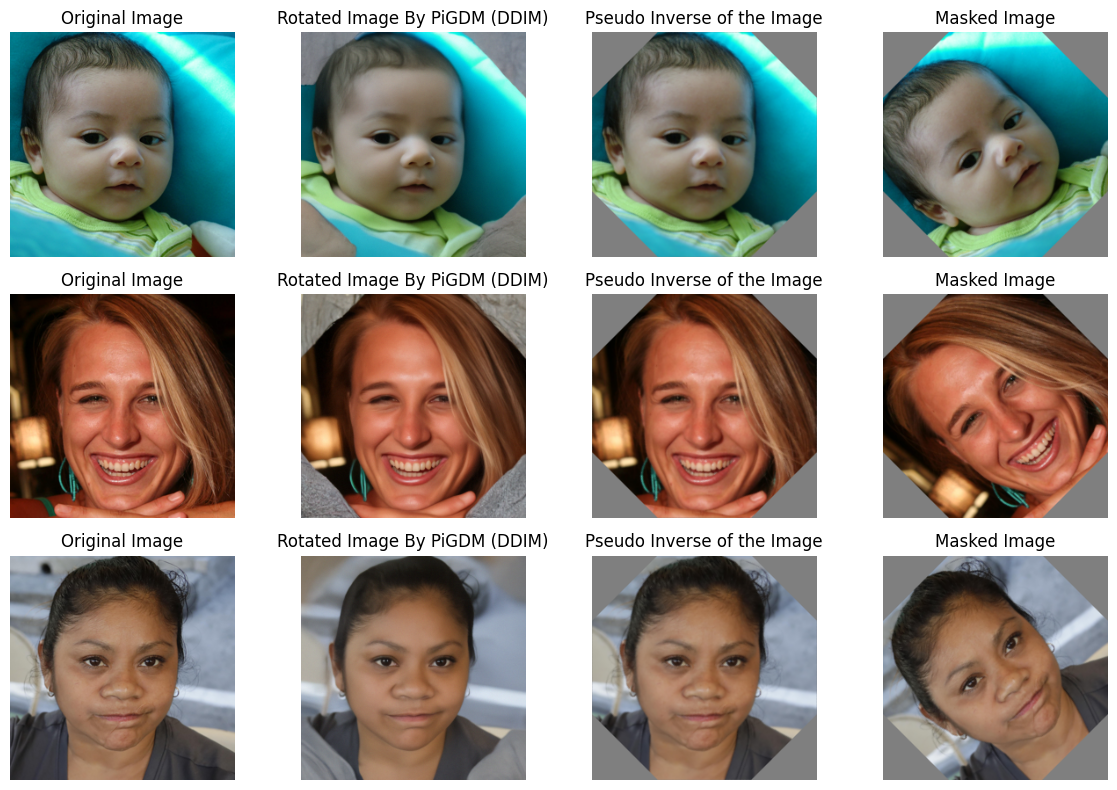

In [ ]:
# Running Experiments on The 3 first images
noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    reconstructed_image = pigdm_sampler_rotation_ddim.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(reconstructed_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Rotated Image By PiGDM (DDIM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Rotated Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [03:57<00:00,  2.38s/it]


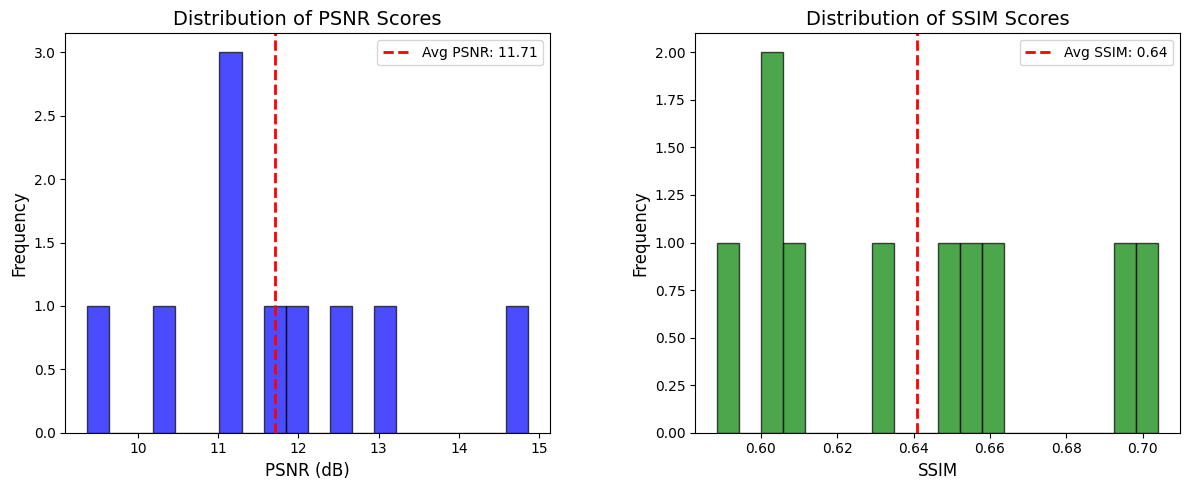

In [46]:
results_ddim_rotation = evaluate_model(pigdm_sampler_rotation_ddim, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddim_rotation)

### DDPM Sampling

In [44]:
# Initialize sampler
pigdm_sampler_rotation_ddpm = PiGDM_DDPM(model, measurement_operator, guidance_factor=guidance_factor)

100%|██████████| 100/100 [03:56<00:00,  2.36s/it]


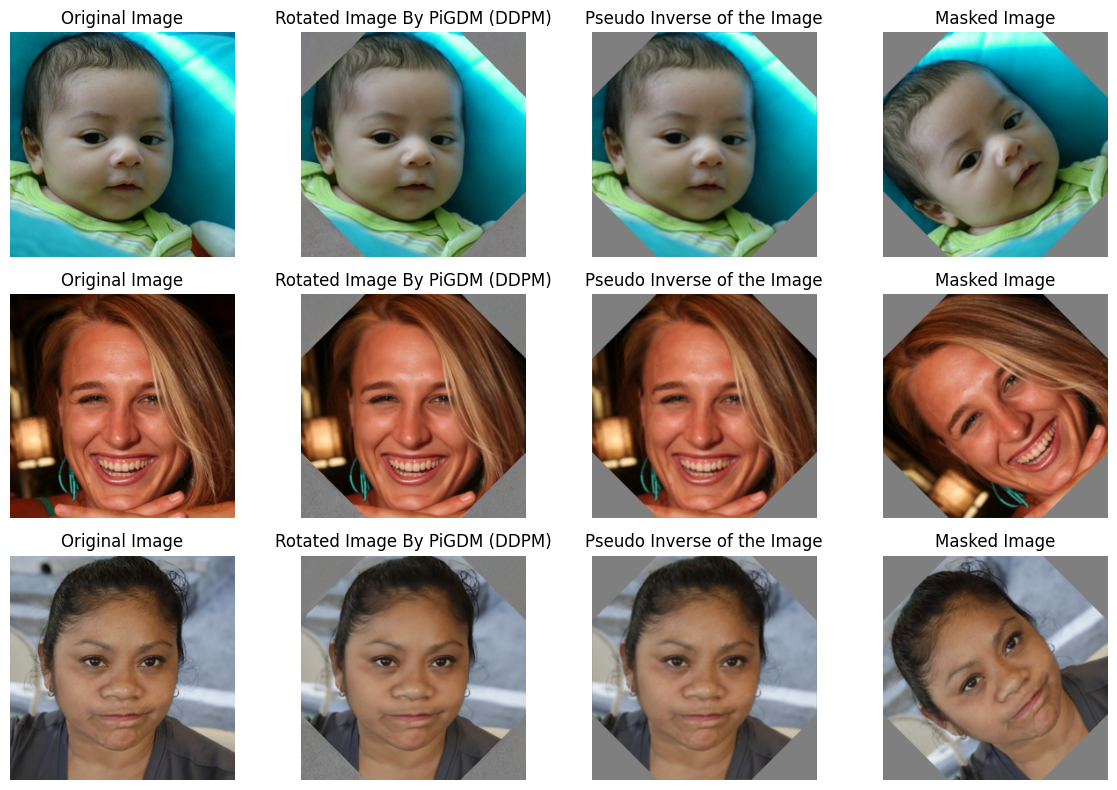

In [ ]:
# Running Experiments on The 3 first images
noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    reconstructed_image = pigdm_sampler_rotation_ddpm.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(reconstructed_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Rotated Image By PiGDM (DDPM)")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Rotated Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [03:28<00:00,  2.09s/it]


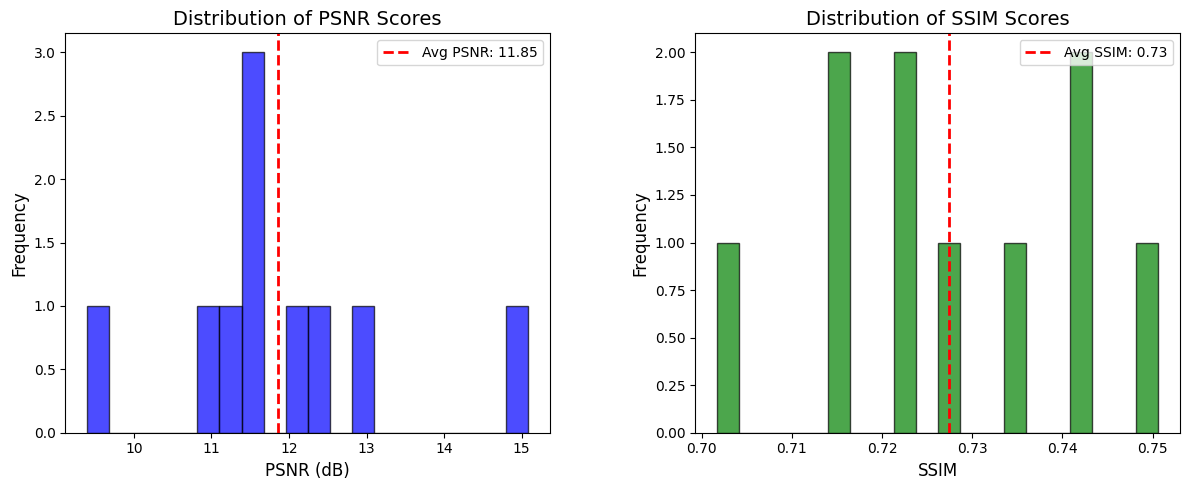

In [47]:
results_ddpm_rotation = evaluate_model(pigdm_sampler_rotation_ddpm, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddpm_rotation)